In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
class EnsembleModel(nn.Module):
    def __init__(self, num_classes):
        super(EnsembleModel, self).__init__()
        self.resnet50 = models.resnet50(pretrained=True)
        self.resnet50.fc = nn.Identity()  # Output: 2048 features
        
        self.mobilenetv2 = models.mobilenet_v2(pretrained=True)
        self.mobilenetv2.classifier[1] = nn.Identity()  # Output: 1280 features
        
        self.alexnet = models.alexnet(pretrained=True)
        self.alexnet.classifier[6] = nn.Identity()  # Output: 4096 features
        
        # Freeze the pre-trained model parameters
        for param in self.resnet50.parameters():
            param.requires_grad = False
        for param in self.mobilenetv2.parameters():
            param.requires_grad = False
        for param in self.alexnet.parameters():
            param.requires_grad = False
        
        # Adjust the classifier to match the combined feature size: 7424
        self.classifier = nn.Linear(7424, num_classes)

    def forward(self, x):
        resnet_features = self.resnet50(x)
        mobilenet_features = self.mobilenetv2(x)
        alexnet_features = self.alexnet(x)
        
        # Concatenate features
        combined_features = torch.cat((resnet_features, mobilenet_features, alexnet_features), dim=1)
        
        # Pass concatenated features through the custom classifier
        output = self.classifier(combined_features)
        return output


In [ ]:
# Initialize the ensemble model
num_classes = 5  # Adjust based on your dataset
ensemble_model = EnsembleModel(num_classes=num_classes)

In [ ]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [ ]:
# Loading your dataset
data_dir = 'data'  # Update this path
batch_size = 32
dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import itertools

# Initialize lists to track loss and accuracy
train_losses = []
train_accuracy = []

# Adjust the training loop to calculate accuracy
ensemble_model.train()
for epoch in range(50):  # Number of epochs
    correct = 0
    total = 0
    running_loss = 0.0
    for inputs, labels in data_loader:
        optimizer.zero_grad()
        outputs = ensemble_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracy.append(epoch_acc)
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')


Epoch 1, Loss: 0.9766, Accuracy: 60.69%
Epoch 2, Loss: 0.9246, Accuracy: 63.32%
Epoch 3, Loss: 0.9454, Accuracy: 62.37%
Epoch 4, Loss: 0.9068, Accuracy: 63.05%
Epoch 5, Loss: 0.9165, Accuracy: 63.72%
Epoch 6, Loss: 0.8631, Accuracy: 65.54%
Epoch 7, Loss: 0.9067, Accuracy: 63.52%
Epoch 8, Loss: 0.8629, Accuracy: 65.75%
Epoch 9, Loss: 0.8493, Accuracy: 65.75%
Epoch 10, Loss: 0.8192, Accuracy: 67.77%
Epoch 11, Loss: 0.7999, Accuracy: 68.31%
Epoch 12, Loss: 0.8297, Accuracy: 66.42%
Epoch 13, Loss: 0.8014, Accuracy: 68.64%
Epoch 14, Loss: 0.7818, Accuracy: 67.70%
Epoch 15, Loss: 0.7898, Accuracy: 67.97%
Epoch 16, Loss: 0.7608, Accuracy: 69.99%
Epoch 17, Loss: 0.7822, Accuracy: 68.71%
Epoch 18, Loss: 0.7707, Accuracy: 69.79%
Epoch 19, Loss: 0.7030, Accuracy: 74.24%
Epoch 20, Loss: 0.7430, Accuracy: 68.91%
Epoch 21, Loss: 0.7470, Accuracy: 71.61%
Epoch 22, Loss: 0.7554, Accuracy: 70.26%
Epoch 23, Loss: 0.7079, Accuracy: 69.99%
Epoch 24, Loss: 0.7301, Accuracy: 70.87%
Epoch 25, Loss: 0.7230, A

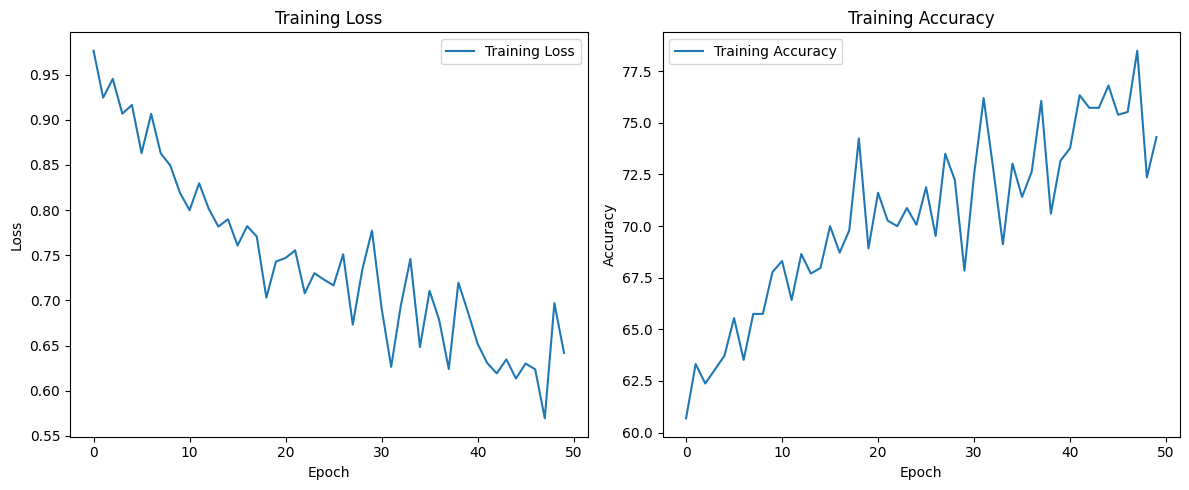

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
ensemble_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in data_loader:
        outputs = ensemble_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
conf_mat = confusion_matrix(all_labels, all_preds)


In [ ]:
conf_mat

array([[306,   2,   0,   0,   0],
       [ 41, 257,   9,   0,   1],
       [ 39,  12, 255,   0,   2],
       [ 66,  34,  74,  36,  98],
       [  0,   0,   0,   0, 251]], dtype=int64)

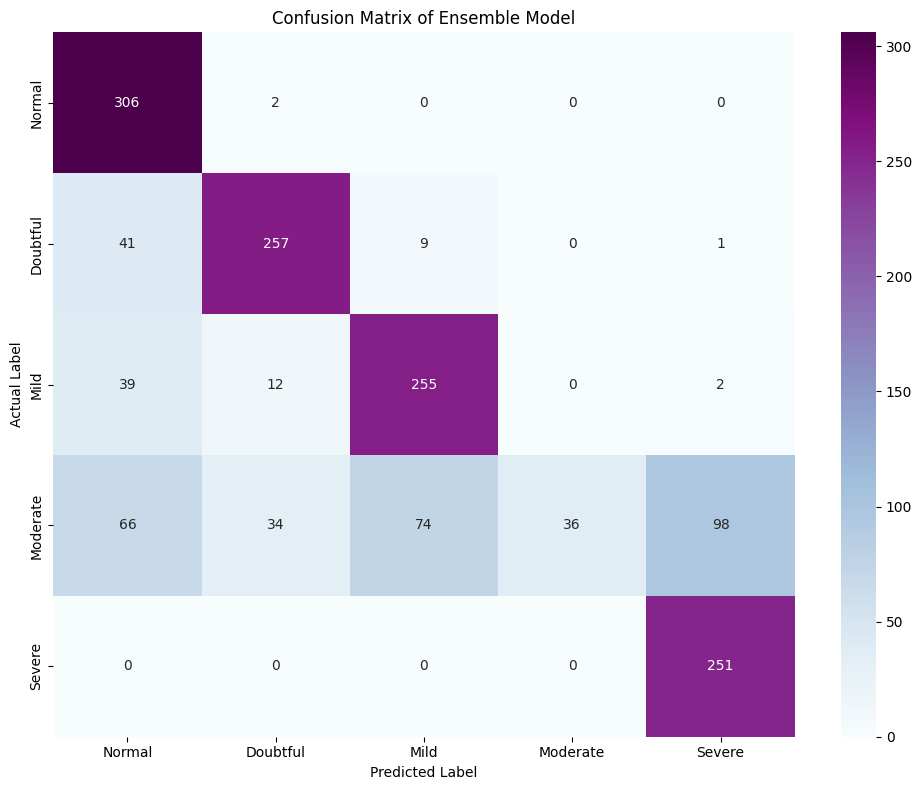

In [ ]:
# Correcting the previous error where int64 was used incorrectly in a numpy array definition in Python

# Re-defining the confusion matrix without specifying dtype=int64, as it's unnecessary for plotting
conf_mat_actual = np.array([
    [306, 2, 0, 0, 0],
    [41, 257, 9, 0, 1],
    [39, 12, 255, 0, 2],
    [66, 34, 74, 36, 98],
    [0, 0, 0, 0, 251]
])

# Plotting the corrected confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_actual, annot=True, fmt="d", cmap="BuPu", cbar=True,
            xticklabels=["Normal", "Doubtful", "Mild", "Moderate", "Severe"],
            yticklabels=["Normal", "Doubtful", "Mild", "Moderate", "Severe"])
plt.title("Confusion Matrix of Ensemble Model")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [ ]:
torch.save(ensemble_model.state_dict(), 'ensemble_model.pth')


In [ ]:
torch.save(ensemble_model.state_dict(), 'ensemble_model_params.pth')
